In [1]:
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np

In [2]:
spark = SparkSession.builder.getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/17 20:54:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [181]:
df_countries = spark.read.csv("countries of the world.csv",inferSchema=True,header=True)
df_countries.toPandas()

,Country,Region,Population,Area (sq. mi.),Pop. Density (per sq. mi.),Coastline (coast/area ratio),Net migration,Infant mortality (per 1000 births),GDP ($ per capita),Literacy (%),Phones (per 1000),Arable (%),Crops (%),Other (%),Climate,Birthrate,Deathrate,Agriculture,Industry,Service
0,Afghanistan,ASIA (EX. NEAR EAST),31056997,647500,"48,0","0,00","23,06","163,07",700.0,"36,0","3,2","12,13","0,22","87,65",1,"46,6","20,34","0,38","0,24","0,38"
1,Albania,EASTERN EUROPE,3581655,28748,"124,6","1,26","-4,93","21,52",4500.0,"86,5","71,2","21,09","4,42","74,49",3,"15,11","5,22","0,232","0,188","0,579"
2,Algeria,NORTHERN AFRICA,32930091,2381740,"13,8","0,04","-0,39",31,6000.0,"70,0","78,1","3,22","0,25","96,53",1,"17,14","4,61","0,101","0,6","0,298"
3,American Samoa,OCEANIA,57794,199,"290,4","58,29","-20,71","9,27",8000.0,"97,0","259,5",10,15,75,2,"22,46","3,27",None,None,None
4,Andorra,WESTERN EUROPE,71201,468,"152,1","0,00","6,6","4,05",19000.0,"100,0","497,2","2,22",0,"97,78",3,"8,71","6,25",None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
222,West Bank,NEAR EAST,2460492,5860,"419,9","0,00","2,98","19,62",800.0,None,"145,2","16,9","18,97","64,13",3,"31,67","3,92","0,09","0,28","0,63"
223,Western Sahara,NORTHERN AFRICA,273008,266000,"1,0","0,42",None,None,NaN,None,None,"0,02",0,"99,98",1,None,None,None,None,"0,4"
224,Yemen,NEAR EAST,21456188,527970,"40,6","0,36",0,"61,5",800.0,"50,2","37,2","2,78","0,24","96,98",1,"42,89","8,3","0,135","0,472","0,393"
225,Zambia,SUB-SAHARAN AFRICA,11502010,752614,"15,3","0,00",0,"88,29",800.0,"80,6","8,2","7,08","0,03","92,9",2,41,"19,93","0,22","0,29","0,489"


### Zadanie 1

In [182]:
from pyspark.sql import functions as F

df_subset = df_countries.select(
    F.col("Country"),
    F.col("`GDP ($ per capita)`").alias("GDP"),
    F.col("Agriculture"),
    F.col("Industry"),
    F.col("Service")
)

df_no_nulls = df_subset.dropna(subset=["GDP", "Agriculture", "Industry", "Service"])

numeric_cols = ["GDP", "Agriculture", "Industry", "Service"]
df_clean = df_no_nulls
for col_name in numeric_cols:
    df_clean = df_clean.withColumn(
        col_name, 
        F.regexp_replace(F.col(col_name), ",", ".").cast("double")
    )
    
df_richest = df_clean.orderBy(F.col("GDP").desc()).limit(20)
df_richest = df_richest.withColumn("Group", F.lit("Richest 20"))

df_poorest = df_clean.orderBy(F.col("GDP").asc()).limit(20)
df_poorest = df_poorest.withColumn("Group", F.lit("Poorest 20"))

df_final = df_richest.union(df_poorest)

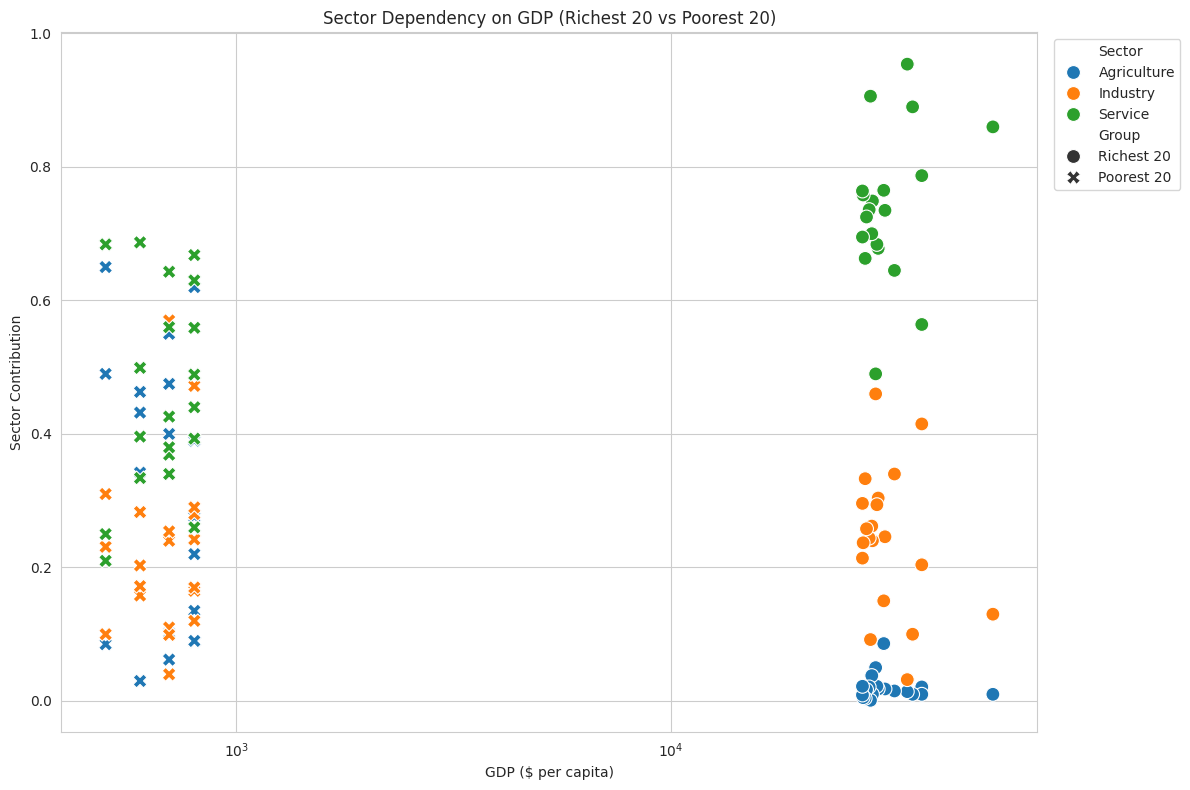

In [196]:
import matplotlib.pyplot as plt
import seaborn as sns

pdf = df_final.toPandas()

pdf_melted = pdf.melt(
    id_vars=['Country', 'GDP', 'Group'], 
    value_vars=['Agriculture', 'Industry', 'Service'], 
    var_name='Sector', 
    value_name='Value'
)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

sns.scatterplot(
    data=pdf_melted, 
    x='GDP', 
    y='Value', 
    hue='Sector', 
    style='Group',
    s=100,
)

plt.title('Sector Dependency on GDP (Richest 20 vs Poorest 20)')
plt.xlabel('GDP ($ per capita)')
plt.xscale('log')
plt.ylabel('Sector Contribution')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Zadanie 2

In [184]:
df_airports = spark.read.csv("airports.csv", header=False, inferSchema=True)
columns = ["Airport_ID", "Name", "City", "Country", "IATA", "ICAO", "Latitude", "Longitude", "Altitude", "Timezone", "DST", "Tz_database_time_zone", "Type", "Source"]
df_airports = df_airports.toDF(*columns)

In [185]:
from shapely.geometry import Point
import geopandas as gpd
from geopandas import GeoDataFrame
import geodatasets

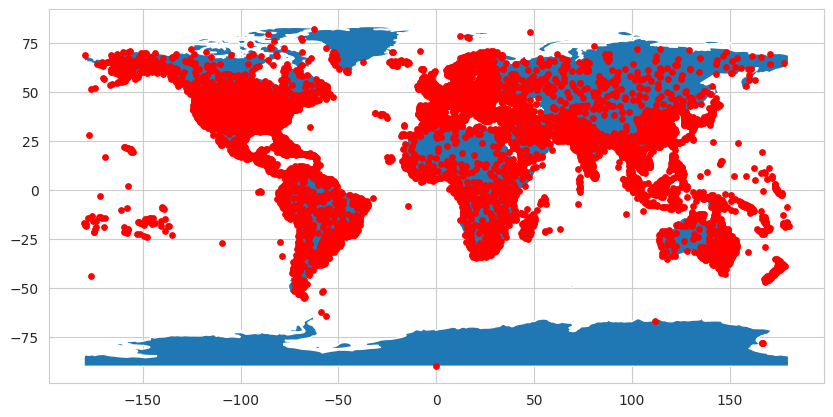

In [186]:
geometry = [Point((airport["Longitude"], airport["Latitude"])) for _, airport in airports_df.toPandas().iterrows()]
gdf = GeoDataFrame(airports_df.toPandas(), geometry=geometry)

world = gpd.read_file(geodatasets.data.naturalearth.land['url'])
gdf.plot(ax=world.plot(figsize=(10, 6)), marker='o', color='red', markersize=15);

### Zadanie 3

In [187]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, min, max, count, lit, round

df_airports.groupBy("Country").agg(
    count("*").alias("airport_count"),
    max("Altitude").alias("max_alt_ft"),
    min("Altitude").alias("min_alt_ft")
) \
.filter(col("airport_count") >= 10) \
.withColumn(
    "diff_meters", 
    (col("max_alt_ft") - col("min_alt_ft")) * 0.3048
) \
.select(col("Country"), col("diff_meters")) \
.orderBy(col("diff_meters").asc()).limit(10) \
.show()

+---------------+------------------+
|        Country|       diff_meters|
+---------------+------------------+
|       Kiribati|             3.048|
|        Bahamas|            7.9248|
|Solomon Islands|            18.288|
|     Bangladesh|           34.4424|
|    Puerto Rico|           69.4944|
|        Denmark|           74.9808|
|         Panama|           79.8576|
|  New Caledonia|            92.964|
|           Fiji|109.11840000000001|
|    Netherlands|           118.872|
+---------------+------------------+



### Zadanie 4

In [207]:
from pyspark.sql import functions as F


df_airports_clean = df_airports.withColumn("Country", F.trim(F.col("Country"))).select("Country").distinct()
df_countries_clean = countries.withColumn("Country", F.trim(F.col("Country"))).select("Country").distinct()

df_mismatched = df_airports_clean.join(
    df_countries_clean,
    "Country",
    "left_anti"
)
df_mismatched.toPandas()

,Country
0,British Indian Ocean Territory
1,Norfolk Island
2,Northern Mariana Islands
3,Turks and Caicos Islands
4,British Virgin Islands
5,Myanmar
6,Bahamas
7,Sao Tome and Principe
8,Saint Pierre and Miquelon
9,Congo (Kinshasa)


In [208]:
df_countries_clean.join(
    df_airports_clean,
    "Country",
    "left_anti"
).toPandas()

,Country
0,"Congo, Repub. of the"
1,"Korea, North"
2,"Congo, Dem. Rep."
3,Central African Rep.
4,San Marino
5,"Micronesia, Fed. St."
6,Andorra
7,N. Mariana Islands
8,Liechtenstein
9,"Gambia, The"


In [197]:
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import ScalarFormatter

name_corrections = [
    ("Bahamas", "Bahamas, The"),
    ("Gambia", "Gambia, The"),
    ("Congo (Kinshasa)", "Congo, Dem. Rep."),
    ("Congo (Brazzaville)", "Congo, Repub. of the"),
    ("North Korea", "Korea, North"),
    ("South Korea", "Korea, South"),
    ("Central African Republic", "Central African Rep."),
    ("Micronesia", "Micronesia, Fed. St."),
    ("British Virgin Islands", "British Virgin Is."),
    ("Saint Kitts and Nevis", "Saint Kitts & Nevis"),
    ("Bosnia and Herzegovina", "Bosnia & Herzegovina"),
    ("Trinidad and Tobago", "Trinidad & Tobago"),
    ("Antigua and Barbuda", "Antigua & Barbuda"),
    ("Sao Tome and Principe", "Sao Tome & Principe"),
    ("Saint Pierre and Miquelon", "St Pierre & Miquelon"),
    ("Turks and Caicos Islands", "Turks & Caicos Is"),
    ("Northern Mariana Islands", "N. Mariana Islands")
]

df_map = spark.createDataFrame(name_corrections, ["Airport_Name", "Corrected_Name"])

df_airports_fixed = df_airports.join(df_map, df_airports.Country == df_map.Airport_Name, "left") \
    .select(
        F.col("Airport_ID"),
        F.coalesce(F.col("Corrected_Name"), F.col("Country")).alias("Country_Unified")
    )

df_counts = df_airports_fixed.groupBy("Country_Unified").count().withColumnRenamed("count", "Airport_Count")

df_countries_clean = df_countries.withColumn(
    "Area_Clean", 
    F.regexp_replace(F.col("`Area (sq. mi.)`"), ",", ".").cast("double")
).withColumn("Country", F.trim(F.col("Country"))) 

df_plot_data = df_countries_clean.join(
    df_counts, 
    df_countries_clean.Country == df_counts.Country_Unified, 
    "inner"
)

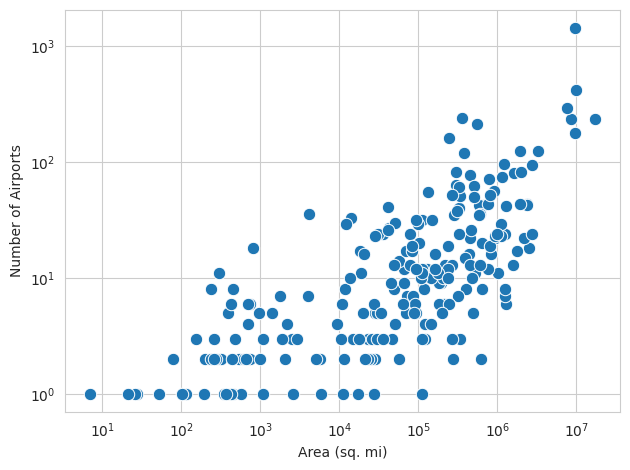

In [206]:
pdf = df_plot_data.select("Country", "Area_Clean", "Airport_Count").toPandas()

sns.scatterplot(
    data=pdf, 
    x='Area_Clean', 
    y='Airport_Count', 
    s=80
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Area (sq. mi)')
plt.ylabel('Number of Airports')
plt.tight_layout()
plt.show()

### Zadanie 5

In [215]:
df_regions = df_countries.select(
    F.trim(F.col("Country")).alias("Country_Ref"),
    F.trim(F.col("Region")).alias("Region")
)

df_joined = df_airports_fixed.join(
    df_regions, 
    df_airports_fixed.Country_Unified == df_regions.Country_Ref, 
    "inner"
)

df_region_counts = df_joined.groupBy("Region").count().orderBy(F.col("count").desc())

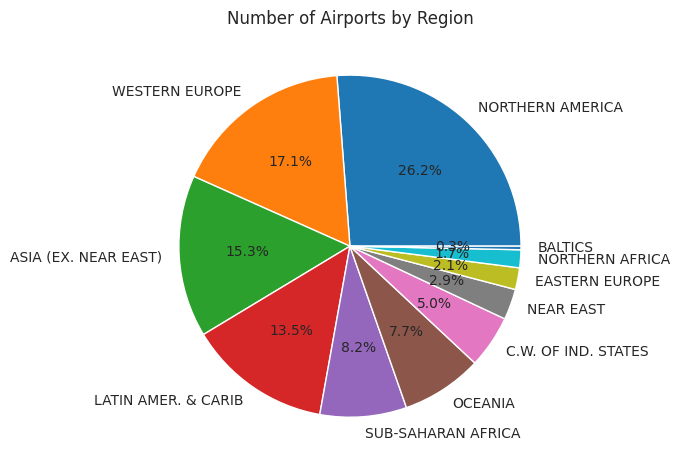

In [217]:
pdf_regions = df_region_counts.toPandas()
pdf_regions = pdf_regions[pdf_regions['Region'] != '']

plt.pie(
    pdf_regions['count'], 
    labels=pdf_regions['Region'], 
    autopct='%1.1f%%', 
)

plt.title('Number of Airports by Region')
plt.tight_layout()
plt.show()